In [ ]:
!pip install legacy-cgi opendatasets -q
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: atigoymas
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:10<00:00, 72.9MB/s]


In [ ]:
import torch
from torch import nn
from torch.optim import Adam
from torchvision.transforms import transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [ ]:
image_path = []
labels = []

for i in os.listdir("/content/animal-faces/afhq"):
  for label in os.listdir(f"/content/animal-faces/afhq/{i}"):
    for image in os.listdir(f"/content/animal-faces/afhq/{i}/{label}"):
      image_path.append(f"/content/animal-faces/afhq/{i}/{label}/{image}")
      labels.append(label)

df = pd.DataFrame(zip(image_path, labels), columns=["image_path", "labels"])
print(df["labels"].unique)
df.head()


<bound method Series.unique of 0         cat
1         cat
2         cat
3         cat
4         cat
         ... 
16125    wild
16126    wild
16127    wild
16128    wild
16129    wild
Name: labels, Length: 16130, dtype: object>


,image_path,labels
0,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


In [ ]:
train = df.sample(frac=0.7)
test = df.drop(train.index)
val = test.sample(frac=0.5)
test = test.drop(val.index)


In [ ]:
label_encoder = LabelEncoder()
label_encoder.fit(df["labels"])

transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.ConvertImageDtype(torch.float)
])

In [ ]:
class CustomImageDataset(Dataset):
  def __init__(self, dataframe, transform=None):
    self.dataframe = dataframe
    self.transform = transform
    self.labels = torch.tensor(label_encoder.transform(dataframe["labels"]))

  def __len__(self):
    return self.dataframe.shape[0]

  def __getitem__(self, idx):
    img_path = self.dataframe.iloc[idx, 0]
    label = self.labels[idx]

    image = Image.open(img_path).convert('RGB')

    if self.transform:
      image = self.transform(image).to(device)

    return image, label



In [ ]:
train_dataset = CustomImageDataset(train, transform=transform)
test_dataset = CustomImageDataset(test, transform=transform)
val_dataset = CustomImageDataset(val, transform=transform)

In [ ]:
train_dataset.__len__()

11291

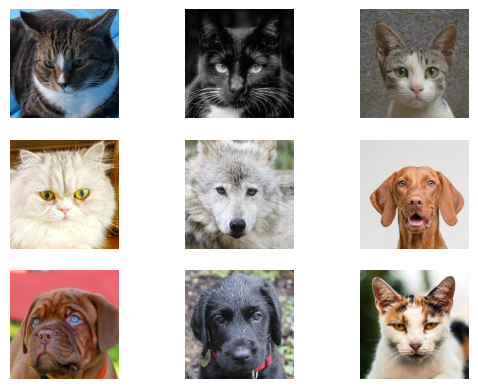

In [ ]:
from IPython.utils.py3compat import no_code
n_rows = 3
n_cols = 3
f, axarr= plt.subplots(n_rows, n_cols)
for row in range(n_rows):
  for col in range(n_cols):
    image = Image.open(df.sample(n=1)["image_path"].iloc[0]).convert("RGB")

    axarr[row, col].imshow(image)
    axarr[row, col].axis('off')
plt.show()

In [ ]:
LR = 1e-4
BATCH_SIZE = 16
EPOCHS = 10

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=True)

In [ ]:
class Net(nn.Module):
  def __init__(self):
    super().__init__()

    self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
    self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
    self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

    self.pooling = nn.MaxPool2d(2, 2)

    self.relu = nn.ReLU()

    self.flatten = nn.Flatten()

    self.linear  = nn.Linear((128*16*16), 128)
    self.output  = nn.Linear(128, len(df['labels'].unique()))

  def forward(self, x):
    x = self.conv1(x) #(32, 128, 128) (output channels, size, size)
    x = self.pooling(x) #(32, 64, 64) (since pool is (2,2), divide by 2)
    x = self.relu(x)

    x = self.conv2(x) #(64, 64, 64) (output channels, size, size)
    x = self.pooling(x) #(64, 32, 32) (since pool is (2,2), divide by 2)
    x = self.relu(x)

    x = self.conv3(x) #(128, 32, 32) (output channels, size, size)
    x = self.pooling(x) #(128, 16, 16) (since pool is (2,2), divide by 2) - This number is passed to the linear layer in output
    x = self.relu(x)

    x = self.flatten(x)
    x = self.linear(x)
    x = self.output(x)

    return x


In [ ]:
model = Net().to(device)

In [ ]:
from torchsummary import summary
summary(model, input_size=(3, 128, 128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 128, 128]             896
         MaxPool2d-2           [-1, 32, 64, 64]               0
              ReLU-3           [-1, 32, 64, 64]               0
            Conv2d-4           [-1, 64, 64, 64]          18,496
         MaxPool2d-5           [-1, 64, 32, 32]               0
              ReLU-6           [-1, 64, 32, 32]               0
            Conv2d-7          [-1, 128, 32, 32]          73,856
         MaxPool2d-8          [-1, 128, 16, 16]               0
              ReLU-9          [-1, 128, 16, 16]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                  [-1, 128]       4,194,432
           Linear-12                    [-1, 3]             387
Total params: 4,288,067
Trainable params: 4,288,067
Non-trainable params: 0
---------------------------

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = LR)

In [ ]:
total_loss_train_plot = []
total_loss_val_plot = []
total_acc_train_plot = []
total_acc_val_plot = []

# Assuming training_data and validation_data datasets exist in your namespace
train_dataset_size = len(train_dataset)
val_dataset_size = len(val_dataset)

for epoch in range(EPOCHS):
  total_acc_train = 0
  total_loss_train = 0
  total_acc_val = 0
  total_loss_val = 0

  # --- TRAINING PHASE ---
  model.train() # Tell PyTorch we are training (enables dropout, etc.)
  for inputs, labels in train_loader:
    # 1. Move both inputs and labels to the GPU
    inputs, labels = inputs.to(device), labels.to(device)

    # 2. Reset gradients FIRST
    optimizer.zero_grad()

    # 3. Forward pass
    output = model(inputs)

    # 4. Calculate batch loss
    train_loss = criterion(output, labels)
    total_loss_train += train_loss.item()

    # 5. Backward pass
    train_loss.backward()

    # 6. Track training correct predictions
    train_acc = (torch.argmax(output, axis=1) == labels).sum().item()
    total_acc_train += train_acc

    # 7. Update weights
    optimizer.step()

  # --- VALIDATION PHASE ---
  model.eval() # Tell PyTorch we are evaluating (disables dropout, etc.)
  with torch.no_grad():
    for inputs, labels in val_loader:
      inputs, labels = inputs.to(device), labels.to(device)

      output = model(inputs)

      val_loss = criterion(output, labels)
      total_loss_val += val_loss.item()

      val_acc = (torch.argmax(output, axis=1) == labels).sum().item()
      total_acc_val += val_acc

  # ─── THESE PLOTS MUST BE INDENTED INSIDE THE EPOCH LOOP ───
  # Store the average batch loss
  total_loss_train_plot.append(total_loss_train / len(train_loader))
  total_loss_val_plot.append(total_loss_val / len(val_loader))

  # Store the actual percentage accuracy (0 - 100%)
  total_acc_train_plot.append((total_acc_train / train_dataset_size) * 100)
  total_acc_val_plot.append((total_acc_val / val_dataset_size) * 100)

  # Rounded output to 4 decimal places for readable tracking
  print(f'''Epoch {epoch+1}/{EPOCHS}
  Train loss: {round(total_loss_train / len(train_loader), 4)} | Train Accuracy: {round((total_acc_train / train_dataset_size) * 100, 2)}%
  Validation Loss: {round(total_loss_val / len(val_loader), 4)} | Validation Accuracy: {round((total_acc_val / val_dataset_size) * 100, 2)}%''')
  print("="*50)

Epoch 1/10
  Train loss: 0.1898 | Train Accuracy: 92.89%
  Validation Loss: 0.1637 | Validation Accuracy: 94.75%
Epoch 2/10
  Train loss: 0.1233 | Train Accuracy: 95.52%
  Validation Loss: 0.1401 | Validation Accuracy: 95.33%
Epoch 3/10
  Train loss: 0.0921 | Train Accuracy: 96.68%
  Validation Loss: 0.1183 | Validation Accuracy: 95.87%
Epoch 4/10
  Train loss: 0.0649 | Train Accuracy: 97.69%
  Validation Loss: 0.1149 | Validation Accuracy: 96.07%
Epoch 5/10
  Train loss: 0.0511 | Train Accuracy: 98.26%
  Validation Loss: 0.1128 | Validation Accuracy: 96.24%
Epoch 6/10
  Train loss: 0.0352 | Train Accuracy: 98.69%
  Validation Loss: 0.1192 | Validation Accuracy: 96.28%
Epoch 7/10
  Train loss: 0.0281 | Train Accuracy: 99.08%
  Validation Loss: 0.118 | Validation Accuracy: 96.2%
Epoch 8/10
  Train loss: 0.0183 | Train Accuracy: 99.39%
  Validation Loss: 0.1835 | Validation Accuracy: 94.26%
Epoch 9/10
  Train loss: 0.0157 | Train Accuracy: 99.51%
  Validation Loss: 0.1859 | Validation Ac

In [ ]:
with torch.no_grad():
  total_loss_test = 0
  total_acc_test = 0
  test_dataset_size = len(test_loader.dataset)

  for inputs, labels in test_loader:
    # Move data to the same device as the model
    inputs, labels = inputs.to(device), labels.to(device)

    predictions = model(inputs)

    acc = (torch.argmax(predictions, axis=1) == labels).sum().item()
    test_loss = criterion(predictions, labels)

    total_loss_test += test_loss.item()
    total_acc_test += acc

print(f'''Test Loss: {round(total_loss_test/len(test_loader), 4)},
Test Accuracy: {round((total_acc_test/test_dataset_size) * 100, 2)}%''')

Test Loss: 0.1981,
Test Accuracy: 94.75%


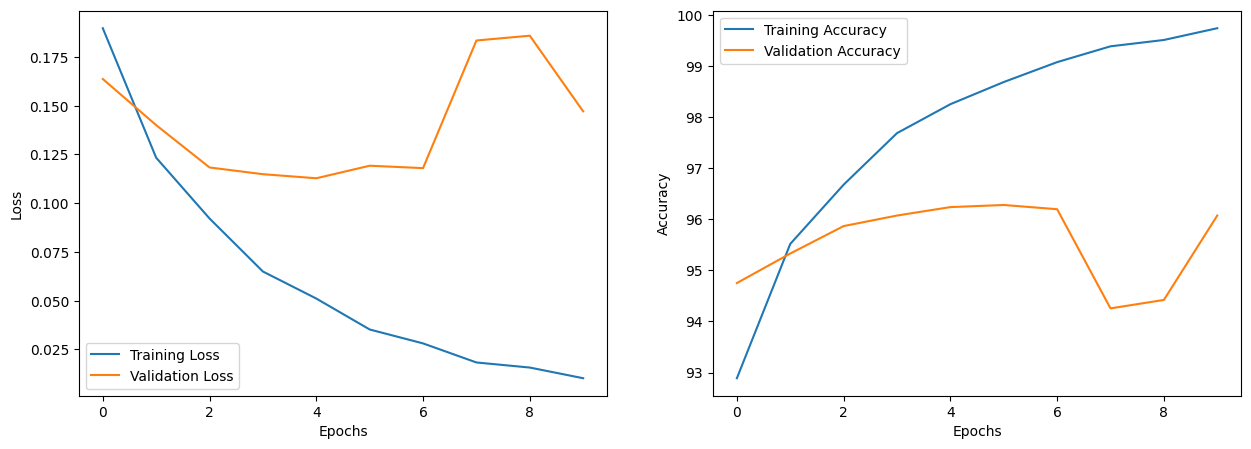

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15, 5))

axs[0].plot(total_loss_train_plot, label='Training Loss')
axs[0].plot(total_loss_val_plot, label='Validation Loss')
axs[0].set_xlabel('Epochs')
axs[0].set_ylabel('Loss')

axs[0].legend()

axs[1].plot(total_acc_train_plot, label='Training Accuracy')
axs[1].plot(total_acc_val_plot, label='Validation Accuracy')
axs[1].set_xlabel('Epochs')
axs[1].set_ylabel('Accuracy')
axs[1].legend()

plt.show()

In [ ]:
def predict_image(image_path):
  image = Image.open(image_path).convert('RGB')
  image = transform(image).to(device)
  output = model(image.unsqueeze(0))

  output = torch.argmax(output, axis=1).item()
  return label_encoder.inverse_transform([output])


In [ ]:
predict_image('/content/WhatsApp Image 2026-09-07 at 22.44.32.jpeg')

array(['wild'], dtype=object)